## Positive Assortative Matching in Marriages in Singapore

This notebook looks at an aggregate-level data set of marriages in Singapore by the broad education level of brides and grooms
(Singapore does not legally recognise same-sex unions).
Given such data a natural question to ask would be whether the marriage market in Singapore exhibits
[positive assortative matching](https://en.wikipedia.org/wiki/Assortative_mating)?

While there are formal family economics models to study this phenomenon, this is not my goal here.
This notebook is just an exercise in writing mixed-content notebooks and publishing it to the web.
Hence the analysis will be quite simple and graphical to provide the minimum amount of needed complexity to test workflows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import requests
import re

### Data

#### Requesting Data

The data is from [data.gov.sg](https://data.gov.sg/).
I use `requests` to fetch the data from the API.

In [2]:
r = requests.get(
    'https://data.gov.sg/api/action/datastore_search',
    params={
        'resource_id': '8a448edd-bc08-42c4-a8c4-33ecdc2398d1',
        'limit': 12*(2017-1983)
    }
)


#### Request Success

Only if the request is successful then should I proceed.
This data is returned in records format, as an array of key-value pairs where the keys are column names.

In [3]:
assert r.status_code == 200, 'Failed to get data'
data = r.json()['result']['records']
data = pd.DataFrame.from_records(data, index='_id')
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 408 entries, 1 to 408
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   value    408 non-null    object
 1   level_1  408 non-null    object
 2   level_2  408 non-null    object
 3   year     408 non-null    object
dtypes: object(4)
memory usage: 15.9+ KB
None


#### Preview

This is what the data looks like.
`level_1` contains the categorical information about brides' broad education level.
`level_2` contains that for grooms.
`year` is as it says on the label.
`value` is the number of registered marriages in that `year` where the bride and groom have those broad education levels.

As shown above, the variables are all in the wrong formats.

In [4]:
print(data.head(6))

     value                     level_1                     level_2  year
_id                                                                     
1    15074                       Total  Grooms - Secondary & Below  1984
2     3126                       Total     Grooms - Post-Secondary  1984
3     1772                       Total         Grooms - University  1984
4    14137  Brides - Secondary & Below  Grooms - Secondary & Below  1984
5     1966  Brides - Secondary & Below     Grooms - Post-Secondary  1984
6      561  Brides - Secondary & Below         Grooms - University  1984


#### Cleaning

Roughly, `year` and `value` need to be converted to integers, then `level_1` and `level_2` need to be renamed and the variable values simplified and converted to categoricals, then total rows can be simplified.

In [5]:
data['year'] = pd.to_numeric(data['year'])
data['value'] = pd.to_numeric(data['value'])
data = data.rename(columns={'level_1':'brides', 'level_2':'grooms'})
data['brides'] = data['brides'].str.replace(r'^brides\W*', '', regex=True, flags=re.I)
data['grooms'] = data['grooms'].str.replace(r'^grooms\W*', '', regex=True, flags=re.I)
data = data[~data['brides'].str.contains(r'^total$', regex=True, flags=re.I)]
data = data[~data['grooms'].str.contains(r'^total$', regex=True, flags=re.I)]
data['brides'] = pd.Categorical(data['brides'], ordered=True, categories=['Secondary & Below', 'Post-Secondary', 'University'])
data['grooms'] = pd.Categorical(data['grooms'], ordered=True, categories=['Secondary & Below', 'Post-Secondary', 'University'])
data.groupby(by=['brides','grooms']).describe()

value                                    \
                                    count         mean          std     min   
brides            grooms                                                      
Secondary & Below Secondary & Below  34.0  6941.500000  3909.518139  1704.0   
                  Post-Secondary     34.0  1640.852941   398.097836   966.0   
                  University         34.0   599.441176    75.002703   407.0   
Post-Secondary    Secondary & Below  34.0  1294.529412   357.596373   688.0   
                  Post-Secondary     34.0  2242.382353   735.708153   804.0   
                  University         34.0  1222.735294   467.433827   413.0   
University        Secondary & Below  34.0   415.147059   218.715275    72.0   
                  Post-Secondary     34.0  1108.323529   825.489890   133.0   
                  University         34.0  4670.470588  3097.269239   743.0   

                                                                         year  \
                                         25%     50%       75%      max count   
brides            grooms                                                        
Secondary & Below Secondary & Below  3646.25  5851.5  10662.75  14137.0  34.0   
                  Post-Secondary     1333.75  1496.5   1984.00   2358.0  34.0   
                  University          569.75   611.0    654.75    709.0  34.0   
Post-Secondary    Secondary & Below   988.50  1270.5   1603.75   1987.0  34.0   
                  Post-Secondary     1861.50  2409.0   2931.00   3181.0  34.0   
                  University          800.50  1371.5   1593.25   1848.0  34.0   
University        Secondary & Below   217.00   432.0    598.75    760.0  34.0   
                  Post-Secondary      369.25   881.5   1853.25   2581.0  34.0   
                  University         1887.75  4256.5   7185.75  10354.0  34.0   

                                                                        \
                                       mean       std     min      25%   
brides            grooms                                                 
Secondary & Below Secondary & Below  2000.5  9.958246  1984.0  1992.25   
                  Post-Secondary     2000.5  9.958246  1984.0  1992.25   
                  University         2000.5  9.958246  1984.0  1992.25   
Post-Secondary    Secondary & Below  2000.5  9.958246  1984.0  1992.25   
                  Post-Secondary     2000.5  9.958246  1984.0  1992.25   
                  University         2000.5  9.958246  1984.0  1992.25   
University        Secondary & Below  2000.5  9.958246  1984.0  1992.25   
                  Post-Secondary     2000.5  9.958246  1984.0  1992.25   
                  University         2000.5  9.958246  1984.0  1992.25   

                                                              
                                        50%      75%     max  
brides            grooms                                      
Secondary & Below Secondary & Below  2000.5  2008.75  2017.0  
                  Post-Secondary     2000.5  2008.75  2017.0  
                  University         2000.5  2008.75  2017.0  
Post-Secondary    Secondary & Below  2000.5  2008.75  2017.0  
                  Post-Secondary     2000.5  2008.75  2017.0  
                  University         2000.5  2008.75  2017.0  
University        Secondary & Below  2000.5  2008.75  2017.0  
                  Post-Secondary     2000.5  2008.75  2017.0  
                  University         2000.5  2008.75  2017.0

#### Reshaping

Nothing looks immediately wrong in the dataset description.
The data is strongly balanced.
I reshape the dataset to a semi-wide format where each row is a year by education level for brides and each column is for an education level for grooms.

In [6]:
data = data.pivot(index=['year','brides'], columns='grooms', values='value')
print(data.head(6))

grooms                  Secondary & Below  Post-Secondary  University
year brides                                                          
1984 Secondary & Below              14137            1966         561
     Post-Secondary                   865            1015         468
     University                        72             145         743
1985 Secondary & Below              12887            1809         533
     Post-Secondary                   832             946         435
     University                        81             154         818


### Exploratory Analysis

#### Raw Data Plots

For a start, I can simply plot the annual counts for each level of bride and groom education level.
The y-axis uses the log scale as growth rates in population-related counts tend to be a constant percentage rather than constant absolute value.

As one would suspect, same-education-level marriages are consistently the most common throughout history.
Intuitively, this clearly shows positive assortative matching.
In the alternative world with independent assortment, the category with the largest margin should also be the most-represented in each individual row or column.
With independent assortment, in 1984 where most individuals had at most high school education, there should be more marriages of brides with some college to grooms with at most high school education than to grooms with some college education.
Similarly, with independent assortment, in 1984 there should be more marriages of brides with at least Bachelor's degrees to grooms with at most high school education than to grooms with at least Bachelor's degrees.
This alternate hypothesis is clearly rejected by the data.

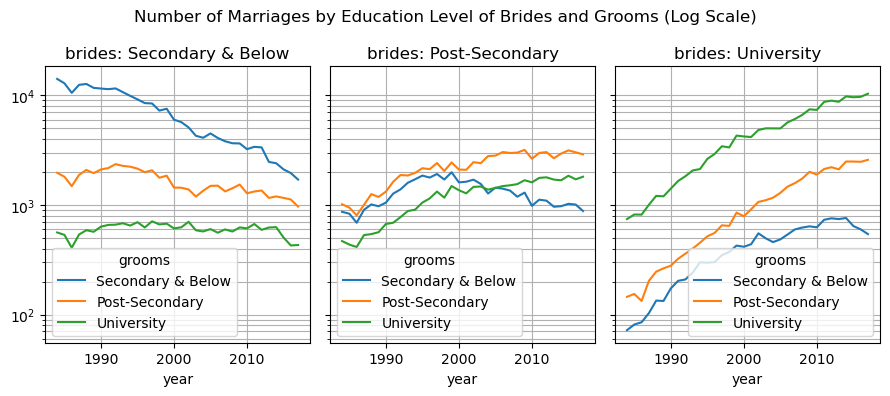

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(9, 4), sharey=True, layout='tight')
for i, c in enumerate(data.index.get_level_values('brides').categories):
    data.loc[pd.IndexSlice[:,c],:].reset_index(level=-1, drop=True).plot(ax=axs[i], title='brides: %s' % c, logy=True)
    axs[i].grid(True, which='both')
fig.suptitle('Number of Marriages by Education Level of Brides and Grooms (Log Scale)')
plt.show()

#### Cell Proportions

Plotting the proportion of all marriages that each cell represents yields nearly the same picture.
It is not nearly so intuitive why this should be the case since the scaling factor changes from year to year.
For intuition, it is possible for some cells to increase over time and other cells to decrease over time, but for some decreasing cells to be constant when represented in proportion terms if the rate of decrease is the same as the rate of decrease in the overall population.
Recall that each cell's proportion in each year is given simply by
$$
    P_{i,j,t} = \frac{N_{i,j,t}}{N_{t}}
$$
and so the rate of change in the proportion is given by
$$
    \Delta \ln P_{i,j,t} = \Big( \Delta \ln N_{i,j,t} \Big) - \Big( \Delta \ln N_{t} \Big).
$$
Intuitively, this also suggests that the number of marriages each year has barely changed between 1984 to 2017.
To see this, one just has to note that if the log change in the proportion is similar to the log change in the level, then the log change in the base rate is essentially zero.
If one computes the total number of marriages, this is indeed the case.
The percent increase in number of marriages registered from 1984 to 2017 is just slightly greater than 10%.

In [8]:
data_props = data.groupby(level='year', group_keys=False).apply(lambda gdf: gdf / gdf.sum().sum())

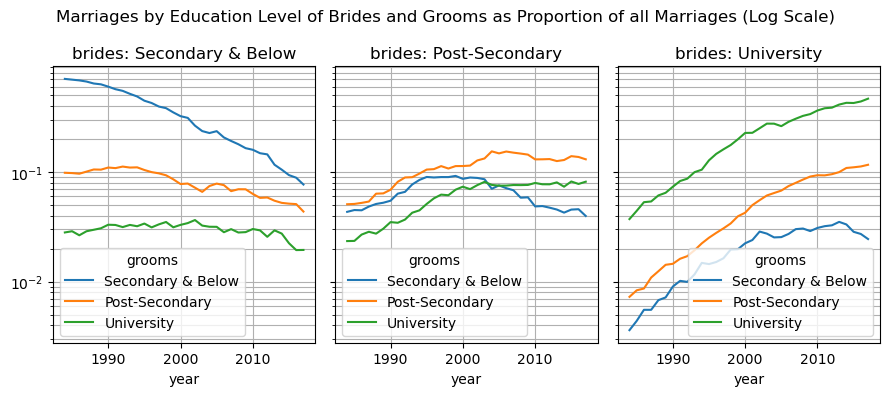

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(9, 4), sharey=True, layout='tight')
for i, c in enumerate(data_props.index.get_level_values('brides').categories):
    data_props.loc[pd.IndexSlice[:,c],:].reset_index(level=-1, drop=True).plot(ax=axs[i], title='brides: %s' % c, logy=True)
    axs[i].grid(True, which='both')
fig.suptitle('Marriages by Education Level of Brides and Grooms as Proportion of all Marriages (Log Scale)')
plt.show()

### Statistical Analyses

#### Contingency Table Association

To formally test positive assortative matching, one needs to compute the rank correlation in the education levels of all marriages.
Because aggregate marriage data is basically a contingency table for each year of data available, one appropriate correlation statistic is [Kendall's $\tau$](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient).
It can be interpreted as the proportion of the distance between no association and perfect association covered by the data.
An association of zero suggests independent assortment while an association of one suggests perfectly positive assortment and negative one suggests perfectly negative assortment.

Given the graphical exploration of the raw data, I already strongly expect the association to be positive.
Hence, asking whether there is positive assortment in the marriage market of Singapore is not interesting.
This would be almost trivial and it would be truly surprising if the answer turned out to be no.
Instead, it could be interesting to ask if the positive assortment in the marriage market of singapore is increasing over time?
This could hint at something about the underlying social structure of Singapore that underpins its marriage market.

In [10]:
def kendalltau_contingency(ctable, order_info=None, **kwargs):
    assert order_info is None or hasattr(order_info, '__getitem__'), 'order_info must be an iterable if provided'
    if isinstance(ctable, np.ndarray) or isinstance(ctable, list):
        ctable = pd.DataFrame(ctable)
    ctable = ctable.unstack(0)
    data = pd.DataFrame.from_records(
        np.repeat(
            ctable.index.to_numpy(),
            ctable.to_numpy()
        )
    )
    if order_info is not None:
        data[data.columns[0]] = pd.Categorical(data.iloc[:,0], categories=order_info, ordered=True).codes
        data[data.columns[1]] = pd.Categorical(data.iloc[:,1], categories=order_info, ordered=True).codes
    return stats.kendalltau(data.iloc[:,0], data.iloc[:,1], **kwargs).statistic

#### Interpreting Kendall's $\tau$

There is strong positive assortation in the marriage market of Singapore by broad education level, as expected.
The $\tau$ statistic is always above 0.5.
The assortation seems to have changed slightly over the years, peaking around the turn of the millenium.
Overall, it is likely safer to say that the marriage market in Singapore has neither become more or less assortative over time without further decades of data.
The stability of the statistic also suggests that the social structure of Singapore that gives rise to the observed structure of its marriage market has been stable for these 4 decades
(or that successive generations of Singaporeans have navigated changes to the social structure of Singapore relatively well without anything of importance to the marriage market changing significantly).

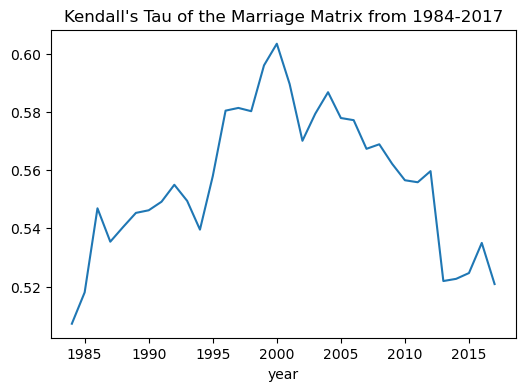

In [11]:
fig, axs = plt.subplots(1, 1, figsize=(6,4))
data.groupby(level='year').apply(lambda gdf: kendalltau_contingency(gdf.reset_index(level=0, drop=True), order_info=['Secondary & Below', 'Post-Secondary', 'University'], variant='b')).plot(ax=axs)
axs.set_title("Kendall's Tau of the Marriage Matrix from 1984-2017")
plt.show()

#### Somers' D

Another ordinal association measure is [Somers' D](https://en.wikipedia.org/wiki/Somers%27_D).
Somers' D is Kendall's $\tau$ normalised by the $\tau$ of a perfectly diagonal matrix defined by the first column of data
(recall that contingency tables are the aggregated summary of two columns of categorical data).
Specifically, $\tau_{c}$ is used to compute Somers' D.
Using $\tau_{b}$ makes no sense as it will always compute a perfect correlation in the denominator for Somers' D.

In comparison to $\tau_{b}$ reported above, Somers' D therefore tells us the proportion of the distance between zero association and perfect association as measured using $\tau_{c}$ that is observed in the data.
The column used for the normalisation matters since $\tau_{c}$ is not always 1 due to allowing rank ties to inflate the denominator.

Given the similarity of the two measures, one can expect Somers' D to tell a similar story as Kendall's $\tau$.
In fact, this is what we observe when the broad education level of grooms is used as the normalisation column.
The story told when the broad education level of brides is used as the normalisation column is interesting:
it suggests that assortation in the marriage market of Singapore has fallen over time.
However, the fall is not very much in absolute terms and we still see that the marriage market of Singapore is strongly positively assorted.

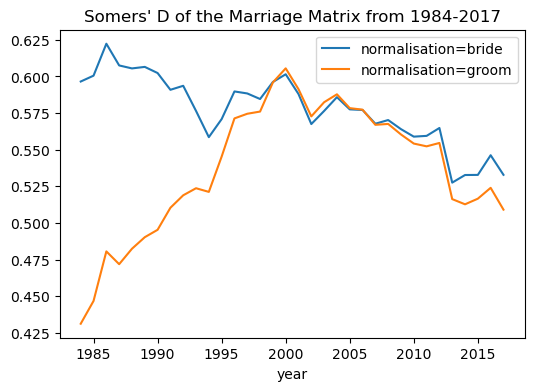

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(6,4))
data.groupby(level='year').apply(lambda gdf: stats.somersd(gdf).statistic).plot(ax=axs, label='normalisation=bride')
data.groupby(level='year').apply(lambda gdf: stats.somersd(gdf.stack(0).unstack(-2)).statistic).plot(ax=axs, label='normalisation=groom')
axs.set_title("Somers' D of the Marriage Matrix from 1984-2017")
axs.legend()
plt.show()

### Concluding Statement

The marriage market of Singapore is strongly assorted along the broad education level dimension and the level of assortment has neither risen nor fallen significantly over the last 4 decades.
This suggests that the social structure that underpins the marriage market is relatively stable.
The implications for socioeconomic mobility would be something of interest.
It would be interesting to compare how these statistics compare to those for the American, British, and European marriage markets.
It would also be interesting to know how much interethnic and international marriages contribute to dampening the level of positive assortment in the marriage market.

That said, this notebook is not for that kind of analysis anyway and has purposely been written only with sufficient complexity to allow for a representative test of notebook-to-web page publication workflows.